# 3) Learning Detection — Sequence Criterion (Strategy 1)

This notebook demonstrates the **Sequence Criterion** learning detection method (Figure 3, “Strategy 1” in the paper).



In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from Functions.standardize_dataset import standardize_dataset
from Functions.set_Beta_prior import set_priors
from Functions.update_strategy_posterior_probability import update_strategy_posterior_probability
from Functions.Summaries_of_Beta_distribution import summaries_of_Beta_Distribution
from Functions.plotSessionStructure import plotSessionStructure
from Functions.interpolate_null_trials import interpolate_null_trials

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import strategymodels

# Load + standardize
from config import data_path, prior_type, decay_rate, save_output_csv, strategy_name
from Functions.standardize_dataset import standardize_dataset

TestData = pd.read_csv(data_path)
TestData = standardize_dataset(TestData)
no_Trials = len(TestData)


[standardize_dataset] Removed 18 omission trial(s) from 'Choice'.


In [2]:
# Load test data

no_Trials = len(TestData)

# Strategies shown in Figure 1
strategies = [
    "go_left",
    "go_right",
    "go_cued",
    "go_uncued",
    "win_stay_spatial",
    "lose_shift_cued",
    "lose_shift_spatial"
]

rule_strategies = ["go_left", "go_right", "go_cued"]


strategy_functions = {}
for s in strategies:
    try:
        strategy_functions[s] = getattr(strategymodels, s)
    except AttributeError:
        raise ValueError(f"Strategy '{s}' not found in strategymodels.")



TestData.head()

,TrialIndex,SessionIndex,TargetRule,Choice,CuePosition,Reward,RuleChangeTrials,NewSessionTrials
0,1,1,go right,right,left,yes,0,0
1,2,1,go right,right,right,yes,0,0
2,3,1,go right,left,left,no,0,0
3,4,1,go right,right,right,yes,0,0
4,5,1,go right,left,left,no,0,0


In [3]:
# Initialise storage
alpha0, beta0 = set_priors(prior_type) 

Output_collection = {}
event_totals = {}

for strategy in strategies:
    
    Output_collection[strategy] = pd.DataFrame(
        columns=[
            "Alpha", "Beta",
            "MAPprobability", "Precision",
            "Alpha_interpolated", "Beta_interpolated",
            "MAPprobability_interpolated", "Precision_interpolated"
        ]
    )
    
    event_totals[strategy] = {
        "success_total": 0,
        "failure_total": 0
    }

In [4]:
# Run Bayesian strategy analysis across trials

for trial in range(len(TestData)):
    
    rows_of_data = TestData.iloc[0:trial+1]
    
    for strategy in strategies:
        
        strategy_fcn = getattr(strategymodels, strategy)
        trial_type = strategy_fcn(rows_of_data)
        
        success_total, failure_total, Alpha, Beta = update_strategy_posterior_probability(
            trial_type,
            decay_rate,
            event_totals[strategy]["success_total"],
            event_totals[strategy]["failure_total"],
            alpha0,
            beta0
        )
        
        event_totals[strategy]["success_total"] = success_total
        event_totals[strategy]["failure_total"] = failure_total
        
        MAPprobability = summaries_of_Beta_Distribution(Alpha, Beta, "MAP")
        precision = summaries_of_Beta_Distribution(Alpha, Beta, "precision")
        
        this_trials_data = {
            "Alpha": Alpha,
            "Beta": Beta,
            "MAPprobability": MAPprobability,
            "Precision": precision
        }
        
        if trial > 0:
            previous_trials_data = Output_collection[strategy].iloc[trial-1]
        else:
            previous_trials_data = Output_collection[strategy]
        
        new_row_of_data = interpolate_null_trials(
            this_trials_data,
            previous_trials_data,
            alpha0,
            beta0
        )
        
        Output_collection[strategy] = pd.concat(
            [Output_collection[strategy], pd.DataFrame([new_row_of_data])],
            ignore_index=True
        )

/var/folders/1p/18jwl7x13xdgtw3zwr3q9zfr0000gn/T/ipykernel_46260/3955232189.py:46: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Output_collection[strategy] = pd.concat(


In [5]:
# Session-end lookup: for each trial, find the last trial index of its session
session_last = TestData.groupby("SessionIndex").apply(lambda g: g.index[-1], include_groups=False)
TestData["session_end_idx"] = TestData["SessionIndex"].map(session_last)
session_end_array = TestData["session_end_idx"].values

print("Session end indices:")
for sid in sorted(TestData["SessionIndex"].unique()):
    end_idx = int(TestData[TestData["SessionIndex"] == sid].index[-1])
    rule = TestData[TestData["SessionIndex"] == sid]["TargetRule"].iloc[0]
    print(f"  Session {sid}: ends at trial index {end_idx}  (rule: {rule})")

Session end indices:
  Session 1: ends at trial index 148  (rule: go right)
  Session 2: ends at trial index 313  (rule: go right)
  Session 3: ends at trial index 463  (rule: go to the lit arm)
  Session 4: ends at trial index 613  (rule: go to the lit arm)
  Session 5: ends at trial index 715  (rule: go to the lit arm)


In [11]:
print(TestData.iloc[313][["TrialIndex", "SessionIndex", "TargetRule"]])
print(TestData.iloc[314][["TrialIndex", "SessionIndex", "TargetRule"]])

TrialIndex                    326
SessionIndex                    2
TargetRule      go to the lit arm
Name: 313, dtype: object
TrialIndex                    331
SessionIndex                    3
TargetRule      go to the lit arm
Name: 314, dtype: object


In [ ]:
def detect_learning_per_block_targeted(Output_collection,
                                       block_starts,
                                       block_ends,
                                       block_target_strategies,
                                       session_end_array,
                                       chance_level=0.5,
                                       min_trials=5):
    """
    For each block, detect learning using the correct strategy for that block.
    Learning criterion: MAP stays above chance_level from trial t until the END OF THE SESSION
    (last trial of the same SessionIndex as trial t — not the block end).
    """
    learning_trials = []

    for start, end, target_strategy in zip(block_starts, block_ends, block_target_strategies):

        MAP = Output_collection[target_strategy]["MAPprobability"].values

        lt = None
        for t in range(start, end):
            sess_end = int(session_end_array[t]) + 1
            remaining = MAP[t:sess_end]
            if len(remaining) >= min_trials and np.all(remaining > chance_level):
                lt = t
                break

        learning_trials.append(lt)

    return learning_trials

if "RuleChangeTrials" in TestData.columns:
    block_boundaries = list(TestData.index[TestData["RuleChangeTrials"] == 1])
else:
    block_boundaries = []

block_starts = [0] + block_boundaries
block_ends   = block_boundaries + [len(TestData)]

if "TargetRule" in TestData.columns:
    block_labels = [TestData.iloc[s]["TargetRule"] for s in block_starts]
else:
    block_labels = ["go right", "go to the lit arm", "go left", "go to the dark arm"][:len(block_starts)]



Block starts: [0, 169]
Block ends:   [169, 716]
Block labels: ['go right', 'go to the lit arm']


In [7]:
# -------------------------------------------------
# Map each task rule to the corresponding strategy
# -------------------------------------------------

rule_to_strategy = {
    "go right": "go_right",
    "Right Arm": "go_right",
    "go to the lit arm": "go_cued",
    "Lit Arm": "go_cued",
    "go left": "go_left",
    "Left Arm": "go_left",
    "go to the dark arm": "go_uncued",
    "Unlit Arm": "go_uncued"
}

block_target_strategies = [rule_to_strategy[label] for label in block_labels]
print("Block labels:", block_labels)
print("Strategy mapping:", block_target_strategies)

Block labels: ['go right', 'go to the lit arm']
Strategy mapping: ['go_right', 'go_cued']


In [8]:
chance_level = 0.5

learning_trials_blocks = detect_learning_per_block_targeted(
    Output_collection=Output_collection,
    block_starts=block_starts,
    block_ends=block_ends,
    block_target_strategies=block_target_strategies,
    session_end_array=session_end_array,
    chance_level=chance_level
)

print("Learning trials per block:", learning_trials_blocks)

Learning trials per block: [22, 438]


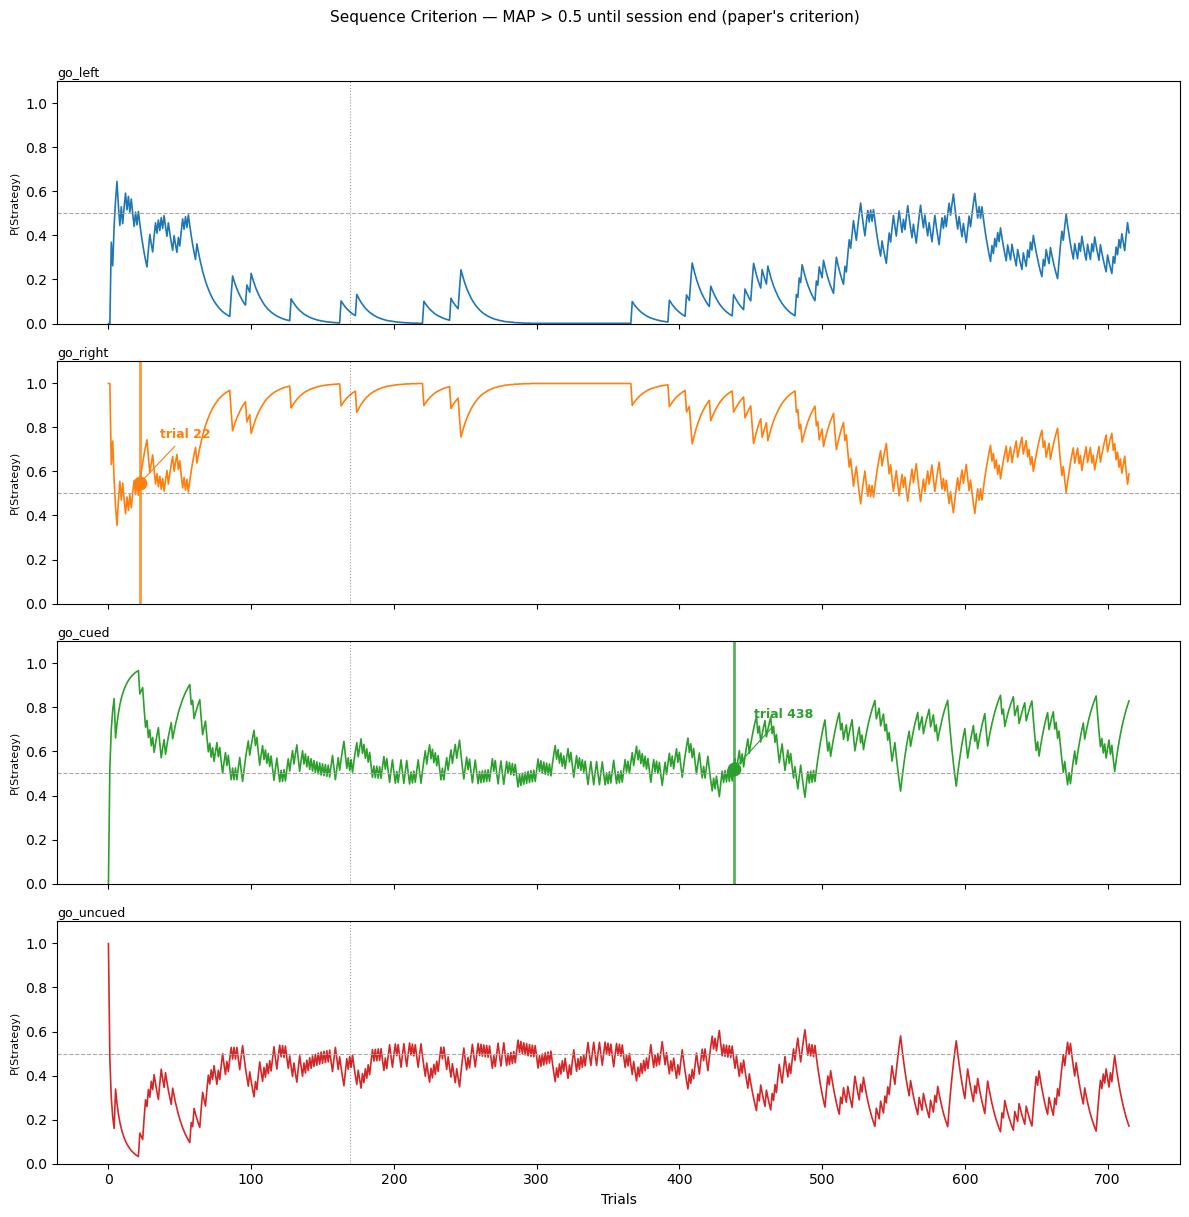


Learning trials per strategy:
  go_left: trial None
  go_right: trial 22
  go_cued: trial 438
  go_uncued: trial None
  win_stay_spatial: trial 130
  lose_shift_cued: trial None
  lose_shift_spatial: trial None


In [9]:
color_map = {
    "go_left":   "#1f77b4",
    "go_right":  "#ff7f0e",
    "go_cued":   "#2ca02c",
    "go_uncued": "#d62728",
}

def detect_learning_session_end(MAP_series, session_end_array, chance_level=0.5, min_trials=5):
    """First trial where MAP stays above chance until end of its session (paper's criterion)."""
    MAP = MAP_series.values
    for t in range(len(MAP)):
        sess_end = int(session_end_array[t]) + 1
        remaining = MAP[t:sess_end]
        if len(remaining) >= min_trials and np.all(remaining > chance_level):
            return t
    return None

# Detect learning for all strategies
learning_trials_all = {}
for strategy in strategies:
    learning_trials_all[strategy] = detect_learning_session_end(
        Output_collection[strategy]["MAPprobability"],
        session_end_array=session_end_array,
        chance_level=0.5
    )

plot_strategies = [s for s in strategies if not s.startswith("win_stay") and not s.startswith("lose_shift")]

n = len(plot_strategies)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

for ax, strategy in zip(axes, plot_strategies):
    MAP = Output_collection[strategy]["MAPprobability"]
    color = color_map.get(strategy, "steelblue")

    ax.plot(MAP, linewidth=1.2, color=color)
    ax.axhline(y=0.5, color="darkgrey", linestyle="--", linewidth=0.8)

    for b in block_boundaries:
        ax.axvline(b, color="black", linestyle=":", linewidth=0.8, alpha=0.4)

    lt = learning_trials_all[strategy]
    if lt is not None:
        ax.axvline(lt, linewidth=2, color=color, alpha=0.8)
        ax.scatter(lt, MAP.values[lt], s=80, color=color, zorder=5)
        ax.annotate(
            f"trial {lt}",
            xy=(lt, MAP.values[lt]),
            xytext=(lt + no_Trials * 0.02, 0.75),
            fontsize=9, color=color, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=color, lw=0.8)
        )

    ax.set_ylabel("P(Strategy)", fontsize=8)
    ax.set_ylim(0, 1.1)
    ax.set_title(strategy, fontsize=9, loc="left", pad=3)

axes[-1].set_xlabel("Trials")
fig.suptitle("Sequence Criterion — MAP > 0.5 until session end (paper's criterion)", fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print("\nLearning trials per strategy:")
for s, lt in learning_trials_all.items():
    print(f"  {s}: trial {lt}")

# NEXT STEP
To compare all three learning criteria, run 4_Learning_Criteria_Comparison.ipynb